## 0. Notebook Objective & Scope
Establish a disciplined, leakage-safe hyperparameter optimization framework for the empirical candidate models identified in Notebooks 3 and 4 across the four Track A cardiovascular prediction tasks (Cath, LAD, LCX, RCA). Tuning is restricted strictly to evidence-backed candidates using a nested cross-validation architecture (outer: 5-fold x 3 repeats = 15 evaluations; inner: 3-fold x 2 repeats = 6 folds per trial) executed exclusively on the 242-patient development cohort. The 61-patient holdout test set remains sealed until Notebook 6.

## 1. Reproducibility & Environment
Configure Optuna with TPESampler(seed=42) and record dependency versions.

In [1]:
import json
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import sklearn
import xgboost as xgb
from lightgbm import LGBMClassifier
from optuna.samplers import TPESampler
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)

print(f"Optuna version:     {optuna.__version__}")
print(f"XGBoost version:    {xgb.__version__}")
print(f"LightGBM version:   {lgb.__version__}")
print(f"scikit-learn:       {sklearn.__version__}")

Optuna version:     4.9.0
XGBoost version:    3.2.0
LightGBM version:   4.6.0
scikit-learn:       1.7.2


## 2. Load Frozen Dataset Contract
Load raw patient records and verify alignment with the locked findings from Notebooks 1, 2, and 3.

In [2]:
with open('preprocessing_config.json', 'r') as f:
    config = json.load(f)

DATA_PATH = Path('extention of Z-Alizadeh sani dataset.xlsx')
df_raw = pd.read_excel(DATA_PATH)
df = df_raw.copy()

df['Sex'] = df['Sex'].replace({'Fmale': 'Female'})
df = df.drop(columns=config['dropped_features'])

TARGET_COLUMNS = config['target_columns']
TARGET_MAPPINGS = config['target_mappings']

y_df = pd.DataFrame(index=df.index)
for target in TARGET_COLUMNS:
    y_df[target] = df[target].map(TARGET_MAPPINGS[target]).astype(int)

X_raw = df.drop(columns=TARGET_COLUMNS).copy()

print(f"Cleaned dataset: {len(X_raw)} rows, {X_raw.shape[1]} candidate features")
assert not any(t in X_raw.columns for t in TARGET_COLUMNS), "Target leakage in X_raw"

TARGETS = {
    'Cath': {'label': 'Overall CAD', 'pos_class': 'CAD'},
    'LAD':  {'label': 'LAD Stenosis', 'pos_class': 'Stenotic'},
    'LCX':  {'label': 'LCX Stenosis', 'pos_class': 'Stenotic'},
    'RCA':  {'label': 'RCA Stenosis', 'pos_class': 'Stenotic'}
}


Cleaned dataset: 303 rows, 54 candidate features


## 3. Verify Development / Holdout Partition
Verify that the 80/20 train/holdout split is identical to Notebook 2 and that the 61-row holdout set is completely sealed.

In [3]:
train_indices = config['train_indices']
holdout_indices = config['holdout_indices']

X_dev = X_raw.iloc[train_indices].copy().reset_index(drop=True)
y_dev = y_df.iloc[train_indices].copy().reset_index(drop=True)

X_holdout = X_raw.iloc[holdout_indices].copy().reset_index(drop=True)
y_holdout = y_df.iloc[holdout_indices].copy().reset_index(drop=True)

assert len(X_dev) == 242, f"Expected 242 development records, got {len(X_dev)}"
assert len(X_holdout) == 61, f"Expected 61 holdout records, got {len(X_holdout)}"
assert len(set(train_indices) & set(holdout_indices)) == 0, "Index overlap detected"

print("HOLDOUT STATUS: SEALED & UNTOUCHED (N=61). Tuning uses exclusively Development (N=242).")

HOLDOUT STATUS: SEALED & UNTOUCHED (N=61). Tuning uses exclusively Development (N=242).


## 4. Load Notebook 3 & 4 Evidence & Candidate Audit
Inspect empirical benchmarks from Notebooks 3 and 4 to construct the selective candidate tuning universe.

In [4]:
nb3_summary = pd.read_csv('artifacts/notebook3_baseline_summary.csv')
nb4_summary = pd.read_csv('artifacts/notebook4_boosting_summary.csv')
nb4_candidates = pd.read_csv('artifacts/notebook4_tuning_candidates.csv')

print("Evidence-based candidate pool imported from Notebooks 3 and 4:")
display(nb4_candidates)

Evidence-based candidate pool imported from Notebooks 3 and 4:


,Target,Candidate Criterion,Model,Preprocessing,ROC-AUC,F1,Recall
0,Cath,Best ROC-AUC,RandomForest,Config_B_OneHot,0.932 +/- 0.039,0.912 +/- 0.026,0.947 +/- 0.039
1,Cath,Best F1,XGBoost,Config_B_OneHot,0.925 +/- 0.039,0.914 +/- 0.028,0.936 +/- 0.042
2,LAD,Best ROC-AUC,RandomForest,Config_A_Ordinal,0.854 +/- 0.056,0.845 +/- 0.046,0.899 +/- 0.047
3,LCX,Best ROC-AUC,XGBoost,Config_B_OneHot,0.750 +/- 0.064,0.549 +/- 0.095,0.515 +/- 0.131
4,LCX,Best F1,XGBoost,Config_A_Ordinal,0.747 +/- 0.063,0.557 +/- 0.090,0.521 +/- 0.128
5,LCX,Best Recall,LightGBM,Config_B_OneHot,0.728 +/- 0.070,0.552 +/- 0.085,0.530 +/- 0.131
6,RCA,Best ROC-AUC,LogisticRegression,Config_A_Ordinal,0.719 +/- 0.057,0.546 +/- 0.087,0.518 +/- 0.110


## 5. Candidate Selection Contract for Tuning
Audit and lock the exact candidate configurations to tune per target. Note: this list deliberately differs from the Notebook 4 export. LCX XGBoost (Config A) and LCX LightGBM (Config B) were replaced by LCX Random Forest (Config B), the best LCX baseline, and RCA Random Forest (Config B) was added as a tree-based comparator to RCA Logistic Regression. This was a manual choice made on development-CV evidence only.

In [5]:
CANDIDATES_TO_TUNE = [
    {'target': 'Cath', 'model_type': 'RandomForest', 'prep': 'Config_B_OneHot', 'reason': 'Top Cath baseline (AUC=0.932)'},
    {'target': 'Cath', 'model_type': 'XGBoost',      'prep': 'Config_B_OneHot', 'reason': 'Top Cath boosting model (F1=0.914)'},
    {'target': 'LAD',  'model_type': 'RandomForest', 'prep': 'Config_A_Ordinal', 'reason': 'Clear LAD benchmark leader (AUC=0.854)'},
    {'target': 'LCX',  'model_type': 'XGBoost',      'prep': 'Config_B_OneHot', 'reason': 'Top LCX boosting model (AUC=0.750, F1=0.549)'},
    {'target': 'LCX',  'model_type': 'RandomForest', 'prep': 'Config_B_OneHot', 'reason': 'Top LCX baseline (AUC=0.745)'},
    {'target': 'RCA',  'model_type': 'LogisticRegression', 'prep': 'Config_A_Ordinal', 'reason': 'Top RCA baseline (AUC=0.719)'},
    {'target': 'RCA',  'model_type': 'RandomForest', 'prep': 'Config_B_OneHot', 'reason': 'Secondary competitive tree candidate'}
]

candidate_audit_df = pd.DataFrame(CANDIDATES_TO_TUNE)
display(candidate_audit_df)
candidate_audit_df.to_csv('artifacts/notebook5_candidate_audit.csv', index=False)
print(f"Total candidate pipelines selected for tuning: {len(CANDIDATES_TO_TUNE)}")

,target,model_type,prep,reason
0,Cath,RandomForest,Config_B_OneHot,Top Cath baseline (AUC=0.932)
1,Cath,XGBoost,Config_B_OneHot,Top Cath boosting model (F1=0.914)
2,LAD,RandomForest,Config_A_Ordinal,Clear LAD benchmark leader (AUC=0.854)
3,LCX,XGBoost,Config_B_OneHot,"Top LCX boosting model (AUC=0.750, F1=0.549)"
4,LCX,RandomForest,Config_B_OneHot,Top LCX baseline (AUC=0.745)
5,RCA,LogisticRegression,Config_A_Ordinal,Top RCA baseline (AUC=0.719)
6,RCA,RandomForest,Config_B_OneHot,Secondary competitive tree candidate


Total candidate pipelines selected for tuning: 7


## 6. Preprocessing Pipelines Construction
Reconstruct ColumnTransformers for Config A (56 features) and Config B (59 features).

In [6]:
fg = config['feature_groups']

ALL_NUMERIC_FEATURES = fg['all_numeric_features']
BINARY_STR_FEATURES = fg['binary_str_features']
BINARY_NUM_FEATURES = fg['binary_num_features']
SEX_FEATURE = fg['sex_feature']
NOMINAL_FEATURES = fg['nominal_features']
ORDINAL_CAT_FEATURES = fg['ordinal_cat_features']

numeric_pipeline = Pipeline([('scaler', StandardScaler())])

binary_str_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(
        categories=[['N', 'Y']] * len(BINARY_STR_FEATURES),
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

sex_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(
        categories=[['Female', 'Male']],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

bbb_pipeline = Pipeline([
    ('ohe', OneHotEncoder(
        categories=[['N', 'LBBB', 'RBBB']],
        handle_unknown='ignore',
        sparse_output=False
    ))
])

vhd_ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(
        categories=[['N', 'mild', 'Moderate', 'Severe']],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

vhd_onehot_pipeline = Pipeline([
    ('ohe', OneHotEncoder(
        categories=[['N', 'mild', 'Moderate', 'Severe']],
        handle_unknown='ignore',
        sparse_output=False
    ))
])

def build_preprocessor(vhd_mode='ordinal'):
    vhd_pipe = vhd_ordinal_pipeline if vhd_mode == 'ordinal' else vhd_onehot_pipeline
    transformers = [
        ('num', numeric_pipeline, ALL_NUMERIC_FEATURES),
        ('bin_str', binary_str_pipeline, BINARY_STR_FEATURES),
        ('sex', sex_pipeline, SEX_FEATURE),
        ('bbb', bbb_pipeline, NOMINAL_FEATURES),
        ('vhd', vhd_pipe, ORDINAL_CAT_FEATURES),
        ('bin_num', 'passthrough', BINARY_NUM_FEATURES)
    ]
    return ColumnTransformer(transformers=transformers, remainder='drop')

PREPROCESSORS = {
    'Config_A_Ordinal': build_preprocessor(vhd_mode='ordinal'),
    'Config_B_OneHot': build_preprocessor(vhd_mode='onehot')
}

for name, p in PREPROCESSORS.items():
    p.fit(X_dev)
    print(f"{name:20s}: {len(p.get_feature_names_out())} output features")

Config_A_Ordinal    : 56 output features
Config_B_OneHot     : 59 output features


## 7. Target-Specific Nested Cross-Validation Strategy
Configure outer CV (5 splits x 3 repeats = 15 evaluations) and inner CV (3 splits x 2 repeats = 6 folds per trial) to prevent optimistic bias.

In [7]:
OUTER_CV_SPLITTERS = {
    target: RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
    for target in TARGET_COLUMNS
}

INNER_CV_SPLITTER = RepeatedStratifiedKFold(n_splits=3, n_repeats=2, random_state=RANDOM_STATE)

print("Nested CV Architecture:")
print("  - Outer Evaluation: 5-Fold x 3 Repeats = 15 Outer Folds per Candidate")
print("  - Inner Search:     3-Fold x 2 Repeats = 6 Inner Folds per Trial")

Nested CV Architecture:
  - Outer Evaluation: 5-Fold x 3 Repeats = 15 Outer Folds per Candidate
  - Inner Search:     3-Fold x 2 Repeats = 6 Inner Folds per Trial


## 8. Model Search Spaces & Budget Definition
Define conservative parameter search spaces. Configured budgets are RF 25, XGBoost 25 and LR 15 trials, but every search is capped at `EFFECTIVE_BUDGET_CAP = 10` Optuna trials per outer fold. The effective budget is therefore 10 trials for every model family.

In [8]:
def sample_params(trial, model_type):
    if model_type == 'RandomForest':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 150, 450, step=50),
            'max_depth': trial.suggest_categorical('max_depth', [None, 3, 5, 7]),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 8),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
            'random_state': RANDOM_STATE,
            'n_jobs': -1
        }
    elif model_type == 'XGBoost':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 150, 400, step=50),
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.10, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 4),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 6),
            'subsample': trial.suggest_float('subsample', 0.70, 0.95, step=0.05),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.70, 0.95, step=0.05),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 1.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 3.0),
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            'random_state': RANDOM_STATE,
            'n_jobs': -1
        }
    elif model_type == 'LogisticRegression':
        return {
            'C': trial.suggest_float('C', 0.01, 10.0, log=True),
            'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
            'solver': 'liblinear',
            'max_iter': 5000,
            'random_state': RANDOM_STATE
        }
    raise ValueError(f"Unknown model_type: {model_type}")

def create_model_instance(model_type, params):
    if model_type == 'RandomForest':
        return RandomForestClassifier(**params)
    elif model_type == 'XGBoost':
        return XGBClassifier(**params)
    elif model_type == 'LogisticRegression':
        return LogisticRegression(**params)
    raise ValueError(f"Unknown model_type: {model_type}")

def build_pipeline(prep_name, model_type, params):
    """Unfitted preprocessing + model pipeline for a given configuration."""
    return Pipeline([
        ('preprocessor', clone(PREPROCESSORS[prep_name])),
        ('model', create_model_instance(model_type, params))
    ])

SEARCH_BUDGETS = {
    'RandomForest': 25,
    'XGBoost': 25,
    'LogisticRegression': 15
}
EFFECTIVE_BUDGET_CAP = 10
EFFECTIVE_BUDGETS = {m: min(b, EFFECTIVE_BUDGET_CAP) for m, b in SEARCH_BUDGETS.items()}
print(f"Tuning budgets configured: {SEARCH_BUDGETS}")
print(f"Effective trials per outer fold (capped): {EFFECTIVE_BUDGETS}")

Tuning budgets configured: {'RandomForest': 25, 'XGBoost': 25, 'LogisticRegression': 15}
Effective trials per outer fold (capped): {'RandomForest': 10, 'XGBoost': 10, 'LogisticRegression': 10}


## 9. Leakage-Safe Nested Tuning Engine
Runs inner Optuna study strictly on each outer training fold, fits selected parameters on outer train, and evaluates on outer validation.

In [9]:
def run_nested_tuning_for_candidate(candidate_info, X, y):
    target = candidate_info['target']
    m_type = candidate_info['model_type']
    prep_name = candidate_info['prep']
    preprocessor = PREPROCESSORS[prep_name]
    budget = EFFECTIVE_BUDGETS[m_type]

    outer_splitter = OUTER_CV_SPLITTERS[target]
    outer_results = []
    trial_logs = []
    best_params_per_fold = []

    print(f"--- Tuning {target} | {m_type} ({prep_name}) [Budget: {budget} trials per fold] ---")

    for outer_fold_idx, (outer_train_i, outer_val_i) in enumerate(outer_splitter.split(X, y)):
        X_out_tr, y_out_tr = X.iloc[outer_train_i], y.iloc[outer_train_i]
        X_out_va, y_out_val = X.iloc[outer_val_i], y.iloc[outer_val_i]

        # Inner CV objective function
        def objective(trial):
            params = sample_params(trial, m_type)
            inner_scores = []

            for inner_train_i, inner_val_i in INNER_CV_SPLITTER.split(X_out_tr, y_out_tr):
                X_in_tr, y_in_tr = X_out_tr.iloc[inner_train_i], y_out_tr.iloc[inner_train_i]
                X_in_va, y_in_val = X_out_tr.iloc[inner_val_i], y_out_tr.iloc[inner_val_i]

                pipe = Pipeline([
                    ('preprocessor', clone(preprocessor)),
                    ('model', create_model_instance(m_type, params))
                ])
                pipe.fit(X_in_tr, y_in_tr)
                prob = pipe.predict_proba(X_in_va)[:, 1]
                inner_scores.append(roc_auc_score(y_in_val, prob))

            mean_inner_auc = float(np.mean(inner_scores))
            trial_logs.append({
                'target': target,
                'model': m_type,
                'preprocessing': prep_name,
                'outer_fold': outer_fold_idx + 1,
                'trial_num': trial.number,
                'inner_auc': mean_inner_auc,
                'params': str(params)
            })
            return mean_inner_auc

        sampler = TPESampler(seed=RANDOM_STATE + outer_fold_idx)
        study = optuna.create_study(direction='maximize', sampler=sampler)
        study.optimize(objective, n_trials=budget)

        best_params = study.best_params
        # Re-attach fixed parameters for refitting
        if m_type == 'RandomForest':
            best_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1})
        elif m_type == 'XGBoost':
            best_params.update({'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': RANDOM_STATE, 'n_jobs': -1})
        elif m_type == 'LogisticRegression':
            best_params.update({'solver': 'liblinear', 'max_iter': 5000, 'random_state': RANDOM_STATE})

        best_params_per_fold.append({
            'outer_fold': outer_fold_idx + 1,
            'best_inner_auc': study.best_value,
            'best_params': best_params
        })

        # Refit best pipeline on outer training fold
        outer_pipe = Pipeline([
            ('preprocessor', clone(preprocessor)),
            ('model', create_model_instance(m_type, best_params))
        ])
        outer_pipe.fit(X_out_tr, y_out_tr)

        # Evaluate on outer validation fold
        out_prob = outer_pipe.predict_proba(X_out_va)[:, 1]
        out_pred = (out_prob >= 0.5).astype(int)

        outer_results.append({
            'target': target,
            'model': m_type,
            'preprocessing': prep_name,
            'outer_fold': outer_fold_idx + 1,
            'repeat': (outer_fold_idx // 5) + 1,
            'fold': (outer_fold_idx % 5) + 1,
            'inner_best_auc': study.best_value,
            'roc_auc': roc_auc_score(y_out_val, out_prob),
            'f1': f1_score(y_out_val, out_pred, zero_division=0),
            'recall': recall_score(y_out_val, out_pred, zero_division=0),
            'precision': precision_score(y_out_val, out_pred, zero_division=0),
            'accuracy': accuracy_score(y_out_val, out_pred),
            'pr_auc': average_precision_score(y_out_val, out_prob)
        })

    return pd.DataFrame(outer_results), pd.DataFrame(trial_logs), best_params_per_fold

## 10. Execute Selective Nested Hyperparameter Tuning
Run nested CV tuning across all selected candidate configurations.

In [10]:
all_outer_results = []
all_trial_logs = []
all_best_params = {}

for cand in CANDIDATES_TO_TUNE:
    t_name = cand['target']
    m_name = cand['model_type']
    p_name = cand['prep']
    key = f"{t_name}__{m_name}__{p_name}"

    out_df, trials_df, best_p = run_nested_tuning_for_candidate(cand, X_dev, y_dev[t_name])
    all_outer_results.append(out_df)
    all_trial_logs.append(trials_df)
    all_best_params[key] = best_p

outer_cv_results_df = pd.concat(all_outer_results, ignore_index=True)
tuning_trials_df = pd.concat(all_trial_logs, ignore_index=True)
print(f"Nested tuning complete! Outer fold evaluations: {len(outer_cv_results_df)}")
display(outer_cv_results_df.head(10))

--- Tuning Cath | RandomForest (Config_B_OneHot) [Budget: 10 trials per fold] ---


--- Tuning Cath | XGBoost (Config_B_OneHot) [Budget: 10 trials per fold] ---


--- Tuning LAD | RandomForest (Config_A_Ordinal) [Budget: 10 trials per fold] ---


--- Tuning LCX | XGBoost (Config_B_OneHot) [Budget: 10 trials per fold] ---


--- Tuning LCX | RandomForest (Config_B_OneHot) [Budget: 10 trials per fold] ---


--- Tuning RCA | LogisticRegression (Config_A_Ordinal) [Budget: 10 trials per fold] ---


--- Tuning RCA | RandomForest (Config_B_OneHot) [Budget: 10 trials per fold] ---


Nested tuning complete! Outer fold evaluations: 105


,target,model,preprocessing,outer_fold,repeat,fold,inner_best_auc,roc_auc,f1,recall,precision,accuracy,pr_auc
0,Cath,RandomForest,Config_B_OneHot,1,1,1,0.937230,0.904082,0.888889,0.914286,0.864865,0.836735,0.953696
1,Cath,RandomForest,Config_B_OneHot,2,1,2,0.900055,0.973469,0.970588,0.942857,1.000000,0.959184,0.991889
2,Cath,RandomForest,Config_B_OneHot,3,1,3,0.925767,0.962637,0.944444,0.971429,0.918919,0.916667,0.986128
3,Cath,RandomForest,Config_B_OneHot,4,1,4,0.918006,0.928571,0.876712,0.941176,0.820513,0.812500,0.973051
4,Cath,RandomForest,Config_B_OneHot,5,1,5,0.947013,0.869748,0.882353,0.882353,0.882353,0.833333,0.946857
5,Cath,RandomForest,Config_B_OneHot,6,2,1,0.913891,0.981633,0.971429,0.971429,0.971429,0.959184,0.994156
6,Cath,RandomForest,Config_B_OneHot,7,2,2,0.917281,0.948980,0.909091,1.000000,0.833333,0.857143,0.976586
7,Cath,RandomForest,Config_B_OneHot,8,2,3,0.924623,0.951648,0.918919,0.971429,0.871795,0.875000,0.982971
8,Cath,RandomForest,Config_B_OneHot,9,2,4,0.929208,0.869748,0.885714,0.911765,0.861111,0.833333,0.946484
9,Cath,RandomForest,Config_B_OneHot,10,2,5,0.958163,0.794118,0.805970,0.794118,0.818182,0.729167,0.906026


## 11. Aggregate Tuned Performance Summary
Mean and standard deviation of outer-CV metrics for tuned candidates.

In [11]:
tuned_summary_df = outer_cv_results_df.groupby(['target', 'model', 'preprocessing']).agg(
    roc_auc_mean=('roc_auc', 'mean'),
    roc_auc_std=('roc_auc', 'std'),
    f1_mean=('f1', 'mean'),
    f1_std=('f1', 'std'),
    recall_mean=('recall', 'mean'),
    recall_std=('recall', 'std'),
    precision_mean=('precision', 'mean'),
    precision_std=('precision', 'std'),
    accuracy_mean=('accuracy', 'mean'),
    accuracy_std=('accuracy', 'std'),
    pr_auc_mean=('pr_auc', 'mean'),
    pr_auc_std=('pr_auc', 'std'),
    inner_auc_mean=('inner_best_auc', 'mean')
).reset_index()

summary_formatted = tuned_summary_df.copy()
for m in ['roc_auc', 'f1', 'recall', 'precision', 'accuracy', 'pr_auc']:
    summary_formatted[m] = summary_formatted.apply(
        lambda r: f"{r[m+'_mean']:.3f} +/- {r[m+'_std']:.3f}", axis=1
    )

display_cols = ['target', 'model', 'preprocessing', 'roc_auc', 'f1', 'recall', 'precision', 'accuracy', 'pr_auc']
display(summary_formatted[display_cols].sort_values(['target', 'roc_auc'], ascending=[True, False]))

,target,model,preprocessing,roc_auc,f1,recall,precision,accuracy,pr_auc
1,Cath,XGBoost,Config_B_OneHot,0.927 +/- 0.046,0.913 +/- 0.028,0.930 +/- 0.040,0.897 +/- 0.033,0.873 +/- 0.039,0.968 +/- 0.025
0,Cath,RandomForest,Config_B_OneHot,0.926 +/- 0.052,0.906 +/- 0.042,0.925 +/- 0.052,0.891 +/- 0.054,0.863 +/- 0.060,0.970 +/- 0.024
2,LAD,RandomForest,Config_A_Ordinal,0.856 +/- 0.050,0.832 +/- 0.041,0.894 +/- 0.064,0.781 +/- 0.052,0.787 +/- 0.052,0.889 +/- 0.042
3,LCX,RandomForest,Config_B_OneHot,0.750 +/- 0.058,0.490 +/- 0.125,0.417 +/- 0.174,0.678 +/- 0.114,0.689 +/- 0.045,0.662 +/- 0.054
4,LCX,XGBoost,Config_B_OneHot,0.725 +/- 0.073,0.518 +/- 0.098,0.481 +/- 0.126,0.587 +/- 0.140,0.664 +/- 0.054,0.623 +/- 0.096
6,RCA,RandomForest,Config_B_OneHot,0.703 +/- 0.047,0.418 +/- 0.116,0.349 +/- 0.158,0.627 +/- 0.115,0.651 +/- 0.031,0.616 +/- 0.054
5,RCA,LogisticRegression,Config_A_Ordinal,0.699 +/- 0.064,0.519 +/- 0.055,0.480 +/- 0.084,0.580 +/- 0.067,0.658 +/- 0.037,0.625 +/- 0.074


## 12. Tuned vs Untuned Baseline Comparison
Evaluate whether hyperparameter optimization yielded a measurable improvement over untuned baselines.

In [12]:
# Load untuned baselines from NB3 and NB4
nb3_b = pd.read_csv('artifacts/notebook3_baseline_summary.csv')
nb4_b = pd.read_csv('artifacts/notebook4_boosting_summary.csv')
untuned_combined = pd.concat([nb3_b, nb4_b], ignore_index=True)

comparison_rows = []
for _, row in tuned_summary_df.iterrows():
    t = row['target']
    m = row['model']
    p = row['preprocessing']

    match = untuned_combined[
        (untuned_combined['target'] == t) &
        (untuned_combined['model'] == m) &
        (untuned_combined['preprocessing'] == p)
    ]
    if len(match) > 0:
        untuned_auc = match['roc_auc_mean'].values[0]
        untuned_f1 = match['f1_mean'].values[0]
        untuned_rec = match['recall_mean'].values[0]

        delta_auc = row['roc_auc_mean'] - untuned_auc
        delta_f1 = row['f1_mean'] - untuned_f1
        delta_rec = row['recall_mean'] - untuned_rec

        comparison_rows.append({
            'Target': t,
            'Model': m,
            'Preprocessing': p,
            'Untuned ROC-AUC': round(untuned_auc, 3),
            'Tuned ROC-AUC': round(row['roc_auc_mean'], 3),
            'Delta ROC-AUC': round(delta_auc, 3),
            'Untuned F1': round(untuned_f1, 3),
            'Tuned F1': round(row['f1_mean'], 3),
            'Delta F1': round(delta_f1, 3),
            'Untuned Recall': round(untuned_rec, 3),
            'Tuned Recall': round(row['recall_mean'], 3),
            'Delta Recall': round(delta_rec, 3)
        })

tuned_vs_baseline_df = pd.DataFrame(comparison_rows)
display(tuned_vs_baseline_df)

,Target,Model,Preprocessing,Untuned ROC-AUC,Tuned ROC-AUC,Delta ROC-AUC,Untuned F1,Tuned F1,Delta F1,Untuned Recall,Tuned Recall,Delta Recall
0,Cath,RandomForest,Config_B_OneHot,0.932,0.926,-0.006,0.912,0.906,-0.005,0.947,0.925,-0.022
1,Cath,XGBoost,Config_B_OneHot,0.925,0.927,0.003,0.914,0.913,-0.001,0.936,0.930,-0.006
2,LAD,RandomForest,Config_A_Ordinal,0.854,0.856,0.002,0.845,0.832,-0.013,0.899,0.894,-0.005
3,LCX,RandomForest,Config_B_OneHot,0.745,0.750,0.005,0.501,0.490,-0.012,0.412,0.417,0.005
4,LCX,XGBoost,Config_B_OneHot,0.750,0.725,-0.025,0.549,0.518,-0.031,0.515,0.481,-0.034
5,RCA,LogisticRegression,Config_A_Ordinal,0.719,0.699,-0.019,0.546,0.519,-0.026,0.518,0.480,-0.038
6,RCA,RandomForest,Config_B_OneHot,0.700,0.703,0.003,0.446,0.418,-0.028,0.366,0.349,-0.017


## 13. Inner vs Outer Generalization Gap Diagnostic
Audit the difference between inner-CV search scores and outer-CV evaluation. Inner-to-outer AUC differences were small across the evaluated candidates, providing no strong evidence of a large tuning-to-evaluation performance gap in this experiment.

In [13]:
gen_gap_df = tuned_summary_df[['target', 'model', 'preprocessing', 'inner_auc_mean', 'roc_auc_mean']].copy()
gen_gap_df['generalization_gap'] = (gen_gap_df['inner_auc_mean'] - gen_gap_df['roc_auc_mean']).round(3)
gen_gap_df.columns = ['Target', 'Model', 'Preprocessing', 'Mean Inner AUC', 'Mean Outer AUC', 'Generalization Gap']
display(gen_gap_df)

,Target,Model,Preprocessing,Mean Inner AUC,Mean Outer AUC,Generalization Gap
0,Cath,RandomForest,Config_B_OneHot,0.926991,0.926244,0.001
1,Cath,XGBoost,Config_B_OneHot,0.920824,0.927421,-0.007
2,LAD,RandomForest,Config_A_Ordinal,0.847949,0.856075,-0.008
3,LCX,RandomForest,Config_B_OneHot,0.737048,0.750344,-0.013
4,LCX,XGBoost,Config_B_OneHot,0.723126,0.724992,-0.002
5,RCA,LogisticRegression,Config_A_Ordinal,0.697087,0.699456,-0.002
6,RCA,RandomForest,Config_B_OneHot,0.701455,0.703167,-0.002


## 14. Stability & Comparison Visualizations
Export performance distribution figures and generalization gap plots.

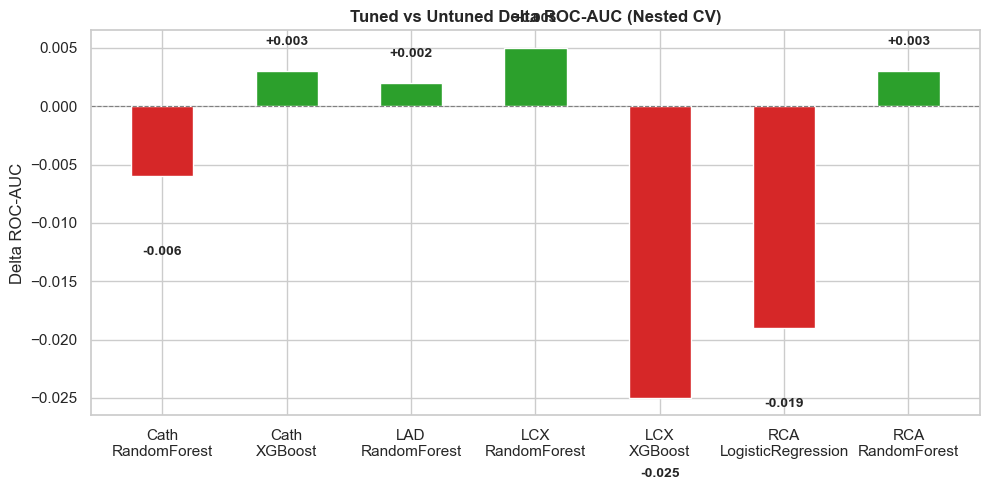

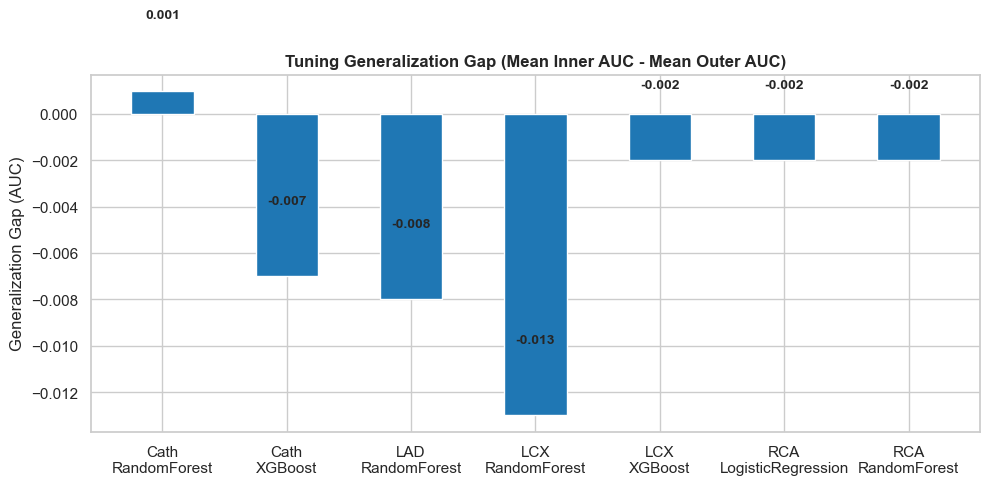

In [14]:
Path('artifacts/figures').mkdir(parents=True, exist_ok=True)

# Plot 1: Tuned vs Untuned ROC-AUC Delta
fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"{r['Target']}\n{r['Model']}" for _, r in tuned_vs_baseline_df.iterrows()]
deltas = tuned_vs_baseline_df['Delta ROC-AUC']
colors = ['#2ca02c' if d >= 0 else '#d62728' for d in deltas]
bars = ax.bar(labels, deltas, color=colors, width=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title("Tuned vs Untuned Delta ROC-AUC (Nested CV)", fontweight='bold')
ax.set_ylabel("Delta ROC-AUC")
for bar in bars:
    yval = bar.get_height()
    offset = 0.002 if yval >= 0 else -0.006
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + offset, f"{yval:+.3f}", ha='center', va='bottom' if yval >= 0 else 'top', fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/figures/notebook5_tuned_vs_baseline_auc.png', dpi=150)
plt.show()

# Plot 2: Generalization Gap Diagnostic
fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"{r['Target']}\n{r['Model']}" for _, r in gen_gap_df.iterrows()]
gaps = gen_gap_df['Generalization Gap']
bars = ax.bar(labels, gaps, color='#1f77b4', width=0.5)
ax.set_title("Tuning Generalization Gap (Mean Inner AUC - Mean Outer AUC)", fontweight='bold')
ax.set_ylabel("Generalization Gap (AUC)")
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.003, f"{yval:.3f}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/figures/notebook5_inner_outer_gap.png', dpi=150)
plt.show()

## 15. Final Candidate Selection & Locked Model Registry
Select one locked model configuration per target using a pre-specified rule: the highest mean outer-CV ROC-AUC. The final hyperparameters come from one inner 3x2 search on all 242 development patients. Differences between the top candidates are small relative to their fold-to-fold SD, so the selection should not be read as evidence that one model family is superior.

In [15]:
final_registry = {}

print('Final Hyperparameter Locking: Running 3-fold x 2-repeat inner CV (10 trials) across ALL 242 dev patients...')

for target in TARGET_COLUMNS:
    t_candidates = tuned_summary_df[tuned_summary_df['target'] == target].sort_values('roc_auc_mean', ascending=False)
    best_cand = t_candidates.iloc[0]
    m_type = best_cand['model']
    prep_name = best_cand['preprocessing']
    y_target_dev = y_dev[target].values

    # Final inner CV on ALL 242 development patients
    inner_cv_final = RepeatedStratifiedKFold(n_splits=3, n_repeats=2, random_state=42)

    def final_objective(trial):
        params = sample_params(trial, m_type)
        scores = []
        for in_tr_idx, in_val_idx in inner_cv_final.split(X_dev, y_target_dev):
            X_in_tr = X_dev.iloc[in_tr_idx]
            y_in_tr = y_target_dev[in_tr_idx]
            X_in_val = X_dev.iloc[in_val_idx]
            y_in_val = y_target_dev[in_val_idx]

            pipe = build_pipeline(prep_name, m_type, params)
            pipe.fit(X_in_tr, y_in_tr)
            y_val_prob = pipe.predict_proba(X_in_val)[:, 1]
            scores.append(roc_auc_score(y_in_val, y_val_prob))
        return np.mean(scores)

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(final_objective, n_trials=10, show_progress_bar=False)

    best_hyperparameters = sample_params(optuna.trial.FixedTrial(study.best_params), m_type)

    final_registry[target] = {
        'target_name': target,
        'clinical_label': TARGETS[target]['label'],
        'selected_model': m_type,
        'preprocessing': prep_name,
        'final_inner_auc_on_242_dev': round(float(study.best_value), 4),
        'hyperparameters': best_hyperparameters,
        'outer_cv_roc_auc': f"{best_cand['roc_auc_mean']:.3f} +/- {best_cand['roc_auc_std']:.3f}",
        'outer_cv_f1': f"{best_cand['f1_mean']:.3f} +/- {best_cand['f1_std']:.3f}",
        'outer_cv_recall': f"{best_cand['recall_mean']:.3f} +/- {best_cand['recall_std']:.3f}"
    }

print('\nLOCKED FINAL MODEL REGISTRY (Ready for Notebook 6 Final Holdout Evaluation):')
for target, info in final_registry.items():
    print(f"Target: {target:5s} ({info['clinical_label']:20s}) -> Model: {info['selected_model']:18s} | Prep: {info['preprocessing']:15s} | 242-Dev Inner AUC: {info['final_inner_auc_on_242_dev']:.4f} | Outer AUC: {info['outer_cv_roc_auc']}")

with open('artifacts/notebook5_final_model_registry.json', 'w') as f:
    json.dump(final_registry, f, indent=4)


Final Hyperparameter Locking: Running 3-fold x 2-repeat inner CV (10 trials) across ALL 242 dev patients...



LOCKED FINAL MODEL REGISTRY (Ready for Notebook 6 Final Holdout Evaluation):
Target: Cath  (Overall CAD         ) -> Model: XGBoost            | Prep: Config_B_OneHot | 242-Dev Inner AUC: 0.9269 | Outer AUC: 0.927 +/- 0.046
Target: LAD   (LAD Stenosis        ) -> Model: RandomForest       | Prep: Config_A_Ordinal | 242-Dev Inner AUC: 0.8602 | Outer AUC: 0.856 +/- 0.050
Target: LCX   (LCX Stenosis        ) -> Model: RandomForest       | Prep: Config_B_OneHot | 242-Dev Inner AUC: 0.7421 | Outer AUC: 0.750 +/- 0.058
Target: RCA   (RCA Stenosis        ) -> Model: RandomForest       | Prep: Config_B_OneHot | 242-Dev Inner AUC: 0.6819 | Outer AUC: 0.703 +/- 0.047


## 16. Save Artifacts & Reproducibility Metadata
Persist all outer-CV results, trial records, and experiment metadata.

In [16]:
outer_cv_results_df.to_csv('artifacts/notebook5_outer_cv_results.csv', index=False)
tuned_summary_df.to_csv('artifacts/notebook5_tuned_summary.csv', index=False)
tuned_vs_baseline_df.to_csv('artifacts/notebook5_tuned_vs_baseline.csv', index=False)
gen_gap_df.to_csv('artifacts/notebook5_generalization_gap.csv', index=False)
tuning_trials_df.to_csv('artifacts/notebook5_tuning_trials.csv', index=False)

metadata = {
    'notebook': '05_Hyperparameter_Tuning.ipynb',
    'optimization_method': 'Optuna TPESampler Nested CV',
    'outer_cv': 'RepeatedStratifiedKFold (5 splits x 3 repeats = 15 outer folds)',
    'inner_cv': 'RepeatedStratifiedKFold (3 splits x 2 repeats = 6 inner folds)',
    'configured_budget': SEARCH_BUDGETS,
    'effective_budget': EFFECTIVE_BUDGETS,
    'effective_budget_cap': EFFECTIVE_BUDGET_CAP,
    'final_hyperparameter_optimization': {
        'cohort': 'ALL 242 development patients',
        'inner_cv': 'RepeatedStratifiedKFold (3 splits x 2 repeats = 6 inner folds)',
        'trials_per_champion': 10
    },
    'candidates_tuned_count': len(CANDIDATES_TO_TUNE),
    'development_cohort_size': len(X_dev),
    'holdout_cohort_size': len(X_holdout),
    'holdout_status': 'SEALED_UNTOUCHED'
}

with open('artifacts/notebook5_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print('Saved all Notebook 5 artifacts and metadata successfully.')


Saved all Notebook 5 artifacts and metadata successfully.


## 17. Final Findings & Handoff to Notebook 6
Synthesize tuning findings and confirm holdout readiness for Notebook 6.

In [17]:
d_auc = tuned_vs_baseline_df['Delta ROC-AUC']
d_f1 = tuned_vs_baseline_df['Delta F1']
rca = tuned_summary_df[tuned_summary_df['target'] == 'RCA'].sort_values('roc_auc_mean', ascending=False)
rca_text = '; '.join(f"{r['model']} ({r['preprocessing']}) {r['roc_auc_mean']:.3f} +/- {r['roc_auc_std']:.3f}" for _, r in rca.iterrows())

findings_summary = pd.DataFrame([
    {
        'Evaluation Question': 'Q1. Did tuning improve ROC-AUC?',
        'Synthesis': (f"No material improvement. Tuned minus untuned mean ROC-AUC ranged from {d_auc.min():+.3f} to {d_auc.max():+.3f}; "
                      f"mean F1 decreased for {(d_f1 < 0).sum()}/{len(d_f1)} candidates. With N=242 the tuning surface is flat.")
    },
    {
        'Evaluation Question': 'Q2. Regularization & Class Weighting',
        'Synthesis': 'Class weighting was part of the Random Forest search space. The LAD champion uses class_weight="balanced", which shifts its probability scale relative to the unweighted LCX/RCA models (see Notebook 7 calibration).'
    },
    {
        'Evaluation Question': 'Q3. RCA Model Selection',
        'Synthesis': f"Nested outer-CV ROC-AUC for RCA candidates: {rca_text}. The difference is far smaller than the fold SD; the choice follows the pre-specified top-mean rule and is not evidence of superiority."
    },
    {
        'Evaluation Question': 'Q4. Inner vs Outer Generalization Gap',
        'Synthesis': 'Inner-to-outer AUC differences were small. The outer folds are the same splits used to shortlist candidates in Notebooks 3-4, so the champion estimates remain somewhat optimistic (model-family selection was not nested).'
    },
    {
        'Evaluation Question': 'Q5. Locked Final Models for Notebook 6',
        'Synthesis': f"Cath: {final_registry['Cath']['selected_model']} ({final_registry['Cath']['preprocessing']}), LAD: {final_registry['LAD']['selected_model']} ({final_registry['LAD']['preprocessing']}), LCX: {final_registry['LCX']['selected_model']} ({final_registry['LCX']['preprocessing']}), RCA: {final_registry['RCA']['selected_model']} ({final_registry['RCA']['preprocessing']})."
    },
    {
        'Evaluation Question': 'Q6. Holdout Status',
        'Synthesis': 'The 61-patient holdout was not used in this notebook.'
    }
])
with pd.option_context('display.max_colwidth', None):
    display(findings_summary)
print('Notebook 5 complete. Model specifications locked for Notebook 6 (Final Evaluation & SHAP).')

,Evaluation Question,Synthesis
0,Q1. Did tuning improve ROC-AUC?,No material improvement. Tuned minus untuned mean ROC-AUC ranged from -0.025 to +0.005; mean F1 decreased for 7/7 candidates. With N=242 the tuning surface is flat.
1,Q2. Regularization & Class Weighting,"Class weighting was part of the Random Forest search space. The LAD champion uses class_weight=""balanced"", which shifts its probability scale relative to the unweighted LCX/RCA models (see Notebook 7 calibration)."
2,Q3. RCA Model Selection,Nested outer-CV ROC-AUC for RCA candidates: RandomForest (Config_B_OneHot) 0.703 +/- 0.047; LogisticRegression (Config_A_Ordinal) 0.699 +/- 0.064. The difference is far smaller than the fold SD; the choice follows the pre-specified top-mean rule and is not evidence of superiority.
3,Q4. Inner vs Outer Generalization Gap,"Inner-to-outer AUC differences were small. The outer folds are the same splits used to shortlist candidates in Notebooks 3-4, so the champion estimates remain somewhat optimistic (model-family selection was not nested)."
4,Q5. Locked Final Models for Notebook 6,"Cath: XGBoost (Config_B_OneHot), LAD: RandomForest (Config_A_Ordinal), LCX: RandomForest (Config_B_OneHot), RCA: RandomForest (Config_B_OneHot)."
5,Q6. Holdout Status,The 61-patient holdout was not used in this notebook.


Notebook 5 complete. Model specifications locked for Notebook 6 (Final Evaluation & SHAP).
